## Initializing data frame

In [1]:
import pandas as pd
pref_germ_df = pd.read_json("./results/preferential_germline_1000.json", dtype=str)
pref_mut_df = pd.read_json("./results/preferential_mutated_1000.json", dtype=str)
uni_germ_df = pd.read_json("./results/uniform_germline_1000.json", dtype=str)
uni_mut_df = pd.read_json("./results/uniform_mutated_1000.json", dtype=str)
rand_germ_df = pd.read_json("./results/random_germline_1000.json", dtype=str)
rand_mut_df = pd.read_json("./results/random_mutated_1000.json", dtype=str)
m8M_germ_df = pd.read_parquet("./results/8M-F_germline_10000.parquet")
m8M_mut_df = pd.read_parquet("./results/8M-F_mutated_10000.parquet")
m35M_germ_df = pd.read_parquet("./results/35M-F_germline_10000.parquet")
m35M_mut_df = pd.read_parquet("./results/35M-F_mutated_10000.parquet")
m150M_germ_df = pd.read_parquet("./results/150M-F_germline_10000.parquet")
m150M_mut_df = pd.read_parquet("./results/150M-F_mutated_10000.parquet")
m350M_germ_df = pd.read_parquet("./results/350M-F_germline_10000.parquet")
m350M_mut_df = pd.read_parquet("./results/350M-F_mutated_10000.parquet")
m650M_germ_df = pd.read_parquet("/home/jovyan/work/AbLM-Metric/results/650M-F_unmutated-per-position-inference.parquet")
m650M_mut_df = pd.read_parquet("/home/jovyan/work/AbLM-Metric/results/650M-F_mutated-per-position-inference.parquet")


for model in ["8M-F", "35M-F", "150M-F", "350M-F", "650M-F"]:
    for data_type in ["Germline", "Mutated"]:
        df = pd.read_parquet(f"./results/{model}_{data_type.lower()}_10000.parquet")
        df["model"], df["data_type"], df["study"] = model, data_type, "size"
        frames.append(df)

pref_germ_df["model"] = "Preferential"
pref_mut_df["model"] = "Preferential"
uni_germ_df["model"] = "Uniform"
uni_mut_df["model"] = "Uniform"
rand_germ_df["model"] = "Random"
rand_mut_df["model"] = "Random"
m8M_germ_df["model"] = "8M-F"
m8M_mut_df["model"] = "8M-F"
m35M_germ_df["model"] = "35M-F"
m35M_mut_df["model"] = "35M-F"
m150M_germ_df["model"] = "150M-F"
m150M_mut_df["model"] = "150M-F"
m350M_germ_df["model"] = "350M-F"
m350M_mut_df["model"] = "350M-F"
m650M_germ_df["model"] = "650M-F"
m650M_mut_df["model"] = "650M-F"

pref_germ_df["data_type"] = "Germline"
pref_mut_df["data_type"] = "Mutated"
uni_germ_df["data_type"] = "Germline"
uni_mut_df["data_type"] = "Mutated"
rand_germ_df["data_type"] = "Germline"
rand_mut_df["data_type"] = "Mutated"
m8M_germ_df["data_type"] = "Germline"
m8M_mut_df["data_type"] = "Mutated"
m35M_germ_df["data_type"] = "Germline"
m35M_mut_df["data_type"] = "Mutated"
m150M_germ_df["data_type"] = "Germline"
m150M_mut_df["data_type"] = "Mutated"
m350M_germ_df["data_type"] = "Germline"
m350M_mut_df["data_type"] = "Mutated"
m650M_germ_df["data_type"] = "Germline"
m650M_mut_df["data_type"] = "Mutated"

pref_germ_df["study"] = "masking"
pref_mut_df["study"] = "masking"
uni_germ_df["study"] = "masking"
uni_mut_df["study"] = "masking"
rand_germ_df["study"] = "masking"
rand_mut_df["study"] = "masking"
m8M_germ_df["study"] = "size"
m8M_mut_df["study"] = "size"
m35M_germ_df["study"] = "size"
m35M_mut_df["study"] = "size"
m150M_germ_df["study"] = "size"
m150M_mut_df["study"] = "size"
m350M_germ_df["study"] = "size"
m350M_mut_df["study"] = "size"
m650M_germ_df["study"] = "size"
m650M_mut_df["study"] = "size"

mask = list(m8M_germ_df["cdr_mask"])
ids = list(m8M_germ_df["id"])
matching = pd.DataFrame({"cdr_mask": mask, "sequence_id": ids})

mask2 = list(m8M_mut_df["cdr_mask"])
ids2 = list(m8M_mut_df["id"])
matching2 = pd.DataFrame({"cdr_mask": mask2, "sequence_id": ids2})

usable_650M_germ_df = pd.merge(matching, m650M_germ_df, on = "sequence_id")
usable_650M_mut_df = pd.merge(matching2, m650M_mut_df, on = "sequence_id")



usable_650M_mut_df.rename(columns={"sequence_aa_heavy": "heavy", "sequence_aa_light":"light"},
                   inplace=True)
usable_650M_germ_df.rename(columns={"sequence_aa_heavy": "heavy", "sequence_aa_light":"light"},
                   inplace=True)
inference_df = pd.concat([pref_germ_df, uni_germ_df, pref_mut_df, uni_mut_df, 
                        rand_germ_df, rand_mut_df,
                         m8M_germ_df, m8M_mut_df, m35M_germ_df, m35M_mut_df, m150M_germ_df, m150M_mut_df, 
                          m350M_mut_df, m350M_germ_df, usable_650M_germ_df, usable_650M_mut_df], 
                         join="inner")




inference_df

,sequence,cdr_mask,heavy,light,prediction,loss,perplexity,model,data_type,study
0,QVQLQESGPGLVKPSQTLSLTCTVSGGSISSGSYYWSWIRQPAGKG...,0000000000000000000000000111111111100000000000...,QVQLQESGPGLVKPSQTLSLTCTVSGGSISSGSYYWSWIRQPAGKG...,QTVVTQEPSFSVSPGGTVTLTCGLSSGSVSTSYYPSWYQQTPGQAP...,QVQLQESGPGLVKPSQTLSLTCTVSGGSISSGSYYWSWIRQPAGKG...,"[5.1258700000000004e-05, 7.2119e-05, 3.05171e-...","[1.00005126, 1.0000721216, 1.0000305176, 1.000...",Preferential,Germline,masking
1,EVQLVESGGGLVKPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,0000000000000000000000000111111110000000000000...,EVQLVESGGGLVKPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,DIVMTQSPLSLPVTPGEPASISCRSSQSLLHSNGYNYLDWYLQKPG...,EVQLVESGGGLVKPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,"[1.53779e-05, 9.5367e-06, 1.49011e-05, 3.20668...","[1.000015378, 1.0000095367, 1.0000149012, 1.00...",Preferential,Germline,masking
2,EVQLVESGGGLVQPGGSLKLSCAASGFTFSGSAMHWVRQASGKGLE...,0000000000000000000000000111111110000000000000...,EVQLVESGGGLVQPGGSLKLSCAASGFTFSGSAMHWVRQASGKGLE...,EIVLTQSPATLSLSPGERATLSCRASQSVSSYLAWYQQKPGQAPRL...,EVQLVESGGGLVQPGGSLKLSCAASGFTFSGSAMHWVRQASGKGLE...,"[1.78812e-05, 6.0797e-06, 1.49011e-05, 9.5367e...","[1.0000178814, 1.0000060797, 1.0000149012, 1.0...",Preferential,Germline,masking
3,EVQLVQSGAEVKKPGESLKISCKGSGYSFTSYWIGWVRQMPGKGLE...,0000000000000000000000000111111110000000000000...,EVQLVQSGAEVKKPGESLKISCKGSGYSFTSYWIGWVRQMPGKGLE...,SYELTQPPSVSVSPGQTARITCSGDALPKQYAYWYQQKPGQAPVLV...,EVQLVQSGAEVKKPGESLKISCKGSGYSFTSYWIGWVRQMPGKGLE...,"[4.78018e-05, 4.42257e-05, 9.73892e-05, 1.9550...","[1.0000478029, 1.0000442266, 1.000097394, 1.00...",Preferential,Germline,masking
4,EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,0000000000000000000000000111111110000000000000...,EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,SSELTQDPAVSVALGQTVRITCQGDSLRSYYASWYQQKPGQAPVLV...,EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,"[1.15632e-05, 8.3446e-06, 1.44242e-05, 1.43050...","[1.0000115633, 1.0000083447, 1.0000144243, 1.0...",Preferential,Germline,masking
...,...,...,...,...,...,...,...,...,...,...
9995,EVQLLESGGGLVQPGGSLRLSCEASGFTFSSYAMSWVRQAPGKGLE...,0000000000000000000000000111111110000000000000...,EVQLLESGGGLVQPGGSLRLSCEASGFTFSSYAMSWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASHSISGNLNWYQQKPEKAPKL...,"[E, V, Q, L, L, E, S, G, G, G, L, V, Q, P, G, ...","[0.01087252888828516, 0.05297795683145523, 0.0...","[1.0109318494796753, 1.0544064044952393, 1.032...",650M-F,Mutated,size
9996,QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,0000000000000000000000000111111110000000000000...,QVQLVQSGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,AIQLTQSPSFLSASVGDRVTITCRASQGISSYLAWYQQKPGKAPKL...,"[Q, V, Q, L, V, Q, S, G, A, E, V, K, K, P, G, ...","[8.344646857949556e-07, 4.0531076592742465e-06...","[1.0000008344650269, 1.0000040531158447, 1.000...",650M-F,Mutated,size
9997,QVQLVQSGAEVKKPGSSVKVSCQASGGTFSSYKVNWVRQAPGQGLE...,0000000000000000000000000111111110000000000000...,QVQLVQSGAEVKKPGSSVKVSCQASGGTFSSYKVNWVRQAPGQGLE...,DIQMTQSPTALSASVGDRITVTCRASQSISGWLAWYQKKPGKAPKL...,"[Q, V, Q, L, V, Q, S, G, A, E, V, K, K, P, G, ...","[0.0190714243799448, 0.136750727891922, 0.2206...","[1.019254446029663, 1.1465423107147217, 1.2468...",650M-F,Mutated,size
9998,QVQLVQSGAEVKKPGDSVKVSCKTSGYTFIAYYIHWVRQVAGQGLE...,0000000000000000000000000111111110000000000000...,QVQLVQSGAEVKKPGDSVKVSCKTSGYTFIAYYIHWVRQVAGQGLE...,QSVLTQPPSASGTPGQRVTISCSGSSSNIGRNAVNWYQQIPGAAPK...,"[Q, V, Q, L, V, Q, S, G, A, E, V, K, K, P, G, ...","[0.005766304675489664, 0.03959428146481514, 0....","[1.005782961845398, 1.040388584136963, 1.14059...",650M-F,Mutated,size


In [2]:
import pandas as pd
import numpy as np
import condensed_blosum_metric
from condensed_blosum_metric import new_scores

# sequencelist = list(inference_df["sequence"])
inferredlist = list(inference_df["prediction"])
region = list(inference_df["cdr_mask"])
filelist = list(inference_df["model"])
file_type_list = list(inference_df["data_type"])
study = list(inference_df["study"])
heavychainlist = list(inference_df["heavy"])
lightchainlist = list(inference_df["light"])
        # find = new_scores(sequencelist[i], inferredlist[i][len(heavychainlist[i]):], region[i][len(heavychainlist[i]):])

sequencelist = lightchainlist

scores_list = []

for i in range (0, len(sequencelist)):
    #find = new_scores(sequencelist[i], inferredlist[i], region[i])
    find = new_scores(sequencelist[i], inferredlist[i][len(heavychainlist[i]):], region[i][len(heavychainlist[i]):])


    scores_list.append({
        "Seq ID": sequencelist[i],
        "Region": "Framework",
        "Metric": find[1],
        "Model": filelist[i],
        "Data Type": file_type_list[i],
        "Median": find[6],
        "Study": study[i]
    })

    scores_list.append({
        "Seq ID": sequencelist[i],
        "Region": "CDR1",
        "Metric": find[2],
        "Model": filelist[i],
        "Data Type": file_type_list[i],
        "Median": find[7],
        "Study": study[i]

    })

    scores_list.append({
        "Seq ID": sequencelist[i],
        "Region": "CDR2",
        "Metric": find[3],
        "Model": filelist[i],
        "Data Type": file_type_list[i],
        "Median": find[8],
        "Study": study[i]

    })

    scores_list.append({
        "Seq ID": sequencelist[i],
        "Region": "CDR3",
        "Metric": find[4],
        "Model": filelist[i],
        "Data Type": file_type_list[i],
        "Median": find[9],
        "Study": study[i]

    })

scores_df = pd.DataFrame(scores_list)

In [3]:
scores_df

,Seq ID,Region,Metric,Model,Data Type,Median,Study
0,QTVVTQEPSFSVSPGGTVTLTCGLSSGSVSTSYYPSWYQQTPGQAP...,Framework,1.000000,Preferential,Germline,1.00,masking
1,QTVVTQEPSFSVSPGGTVTLTCGLSSGSVSTSYYPSWYQQTPGQAP...,CDR1,1.000000,Preferential,Germline,1.00,masking
2,QTVVTQEPSFSVSPGGTVTLTCGLSSGSVSTSYYPSWYQQTPGQAP...,CDR2,1.000000,Preferential,Germline,1.00,masking
3,QTVVTQEPSFSVSPGGTVTLTCGLSSGSVSTSYYPSWYQQTPGQAP...,CDR3,1.000000,Preferential,Germline,1.00,masking
4,DIVMTQSPLSLPVTPGEPASISCRSSQSLLHSNGYNYLDWYLQKPG...,Framework,1.000000,Preferential,Germline,1.00,masking
...,...,...,...,...,...,...,...
423995,QSVLTQPPSASGTPGQRVTISCSGSSSNIGRNAVNWYQQIPGAAPK...,CDR3,0.794415,650M-F,Mutated,1.00,size
423996,QTVVAQEPSFSVSPGGTVTLTCGLTSGSVSTTHYPSWYQQTPGQSP...,Framework,0.928248,650M-F,Mutated,1.00,size
423997,QTVVAQEPSFSVSPGGTVTLTCGLTSGSVSTTHYPSWYQQTPGQSP...,CDR1,0.936511,650M-F,Mutated,1.00,size
423998,QTVVAQEPSFSVSPGGTVTLTCGLTSGSVSTTHYPSWYQQTPGQSP...,CDR2,0.857133,650M-F,Mutated,1.00,size


## Plots

## histograms

### regional histogram

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

if sequencelist == heavychainlist:
    chain_type = "Heavy"
elif sequencelist == lightchainlist:
    chain_type = "Light"
else: print("There is an incorrect variable assignment for the sequence list")

reg = "CDR3"
data_type = "Mutated"
calculation_type = "Metric"
study = "size"

title = f"{chain_type} chain {reg} {data_type}"
saved_png = f"{study} study {title}".title()


Mods = {
    "mod1": "8M-F",
    "mod2": "35M-F",
    "mod3": "150M-F",
    "mod4": "350M-F",
    "mod5": "650M-F"
}

Colors = {
    "col1": "#54BCD1FF",
    "col2": "crimson",
    "col3": "#8FDA04FF",
    "col4": "indigo",
    "col5": "deeppink"
    # "col1": "#C70E7BFF",
    # "col2": "#FC6882FF",
    # "col3": "#8FDA04FF",
    # "col4": "#54BCD1FF",
    # "col5": "#EFC7E6FF"
}

'''The color scheme for the random, preferential, and uniform models is: yellow, purple, red for the histograms and #F8FF83, #84E3FF, #F01035 for the boxplots'''


'The color scheme for the random, preferential, and uniform models is: yellow, purple, red for the histograms and #F8FF83, #84E3FF, #F01035 for the boxplots'

/tmp/ipykernel_34239/2359976065.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  hist_1 = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == Mods.get("mod1")][scores_df["Region"] == reg]["Metric"],
/tmp/ipykernel_34239/2359976065.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  hist_1 = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == Mods.get("mod1")][scores_df["Region"] == reg]["Metric"],
/tmp/ipykernel_34239/2359976065.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  hist_2 = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == Mods.get("mod2")][scores_df["Region"] == reg]["Metric"],
/tmp/ipykernel_34239/2359976065.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  hist_2 = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == Mods.get("mod2")]

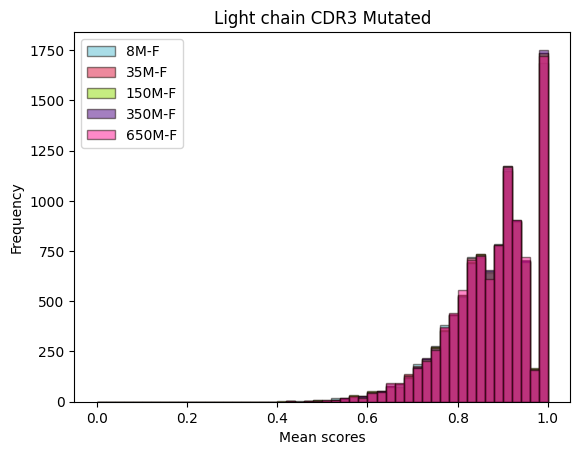

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

hist_1 = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == Mods.get("mod1")][scores_df["Region"] == reg]["Metric"], 
        label = Mods.get("mod1"), range = [0,1], bins=50, 
        color = Colors.get("col1"), alpha = 0.5, edgecolor = "#140700")
hist_2 = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == Mods.get("mod2")][scores_df["Region"] == reg]["Metric"], 
        label = Mods.get("mod2"), alpha = 0.5, range = [0,1], bins=50, 
        color = Colors.get("col2"), edgecolor = "#140700")
hist_3 = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == Mods.get("mod3")][scores_df["Region"] == reg]["Metric"], 
        label = Mods.get("mod3"), alpha = 0.5, range = [0,1], bins=50, 
        color = Colors.get("col3"), edgecolor = "#140700")
hist_4 = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == Mods.get("mod4")][scores_df["Region"] == reg]["Metric"], 
        label = Mods.get("mod4"), alpha = 0.5, range = [0,1], bins=50, 
        color = Colors.get("col4"), edgecolor = "#140700")
hist_5 = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == Mods.get("mod5")][scores_df["Region"] == reg]["Metric"], 
        label = Mods.get("mod5"), alpha = 0.5, range = [0,1], bins=50, 
        color = Colors.get("col5"), edgecolor = "#140700")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, title='Model')
plt.title(title)
plt.ylabel("Frequency")
plt.xlabel("Mean scores")
plt.legend()
plt.savefig(f"./results/hist-{saved_png}.png", bbox_inches='tight')


### non regional/whole sequence histogram

## Boxplots

/tmp/ipykernel_34239/2625913028.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plot = sns.boxplot(x = "Region", y = calculation_type, data = scores_df[scores_df["Data Type"] == data_type][scores_df["Study"]== study], hue="Model",
/tmp/ipykernel_34239/2625913028.py:5: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  plot = sns.boxplot(x = "Region", y = calculation_type, data = scores_df[scores_df["Data Type"] == data_type][scores_df["Study"]== study], hue="Model",
/opt/conda/lib/python3.12/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/opt/conda/lib/python3.12/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.b

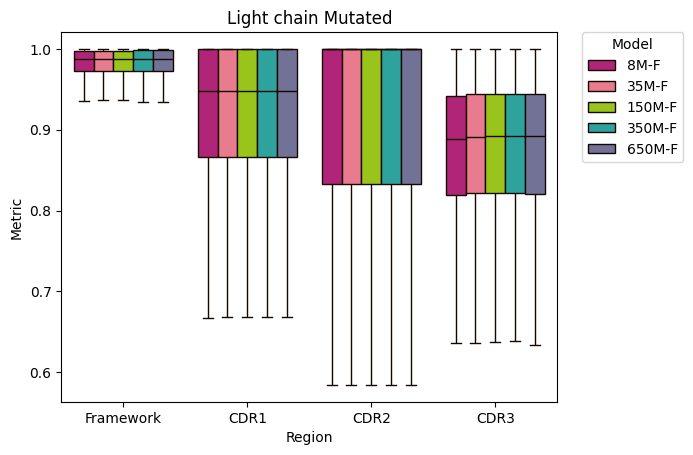

<Figure size 640x480 with 0 Axes>

In [6]:
from pypalettes import load_palette
#Klein and PassionFruit are nice color palettes 


plot = sns.boxplot(x = "Region", y = calculation_type, data = scores_df[scores_df["Data Type"] == data_type][scores_df["Study"]== study], hue="Model", 
        showfliers = False, palette=load_palette("PassionFruit"), linecolor = "#140700").set(title = f"{chain_type} chain {data_type}")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, title='Model')
plt.ylabel(calculation_type)
plt.show()
plt.savefig(f"./results/box-{study} {chain_type} Chain {data_type}.png", format = "png")


In [7]:
scores_df[scores_df["Data Type"] == data_type][scores_df["Study"]== study].head()

/tmp/ipykernel_34239/1044853637.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  scores_df[scores_df["Data Type"] == data_type][scores_df["Study"]== study].head()


,Seq ID,Region,Metric,Model,Data Type,Median,Study
64000,SYVLTQPPSVSLAPGKTARITCGGYNIETKSVHWYQQKPAQAPVLV...,Framework,0.968466,8M-F,Mutated,1.0,size
64001,SYVLTQPPSVSLAPGKTARITCGGYNIETKSVHWYQQKPAQAPVLV...,CDR1,0.775133,8M-F,Mutated,1.0,size
64002,SYVLTQPPSVSLAPGKTARITCGGYNIETKSVHWYQQKPAQAPVLV...,CDR2,1.000000,8M-F,Mutated,1.0,size
64003,SYVLTQPPSVSLAPGKTARITCGGYNIETKSVHWYQQKPAQAPVLV...,CDR3,0.839582,8M-F,Mutated,1.0,size
64004,DIVMTQSPDSLAVSLGERATINCKSSQSVFFNSNKRNYLAWYQQKP...,Framework,0.972392,8M-F,Mutated,1.0,size


In [8]:
scores_df[(scores_df["Data Type"] == data_type) & (scores_df["Study"]== study) & (scores_df["Region"]=="CDR3")].head()

,Seq ID,Region,Metric,Model,Data Type,Median,Study
64003,SYVLTQPPSVSLAPGKTARITCGGYNIETKSVHWYQQKPAQAPVLV...,CDR3,0.839582,8M-F,Mutated,1.0,size
64007,DIVMTQSPDSLAVSLGERATINCKSSQSVFFNSNKRNYLAWYQQKP...,CDR3,0.782156,8M-F,Mutated,1.0,size
64011,QSVLTQPPSVSGTPGQRVSMSCAGGSSNIGSKPVNWYQQLPGRAPK...,CDR3,0.857142,8M-F,Mutated,1.0,size
64015,QPVLTQSSSVSASLGSLVKLTCTLSSGHSNYIIAWHQQQPGKAPRY...,CDR3,0.777522,8M-F,Mutated,1.0,size
64019,QSALTQPASVSGSPGQSITISCTGTNSDVGTSNYVSWYQQHPGKVP...,CDR3,0.837500,8M-F,Mutated,1.0,size


In [9]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Define the model
model = ols('Metric ~ C(Model)', data=scores_df[(scores_df["Data Type"] == data_type) & (scores_df["Study"]== study) & (scores_df["Region"]=="Framework")]).fit()

# Perform ANOVA
anova_table = sm.stats.anova_lm(model, typ=1)
print(anova_table)

               df     sum_sq   mean_sq         F    PR(>F)
C(Model)      4.0   0.000042  0.000011  0.030862  0.998172
Residual  49995.0  17.164713  0.000343       NaN       NaN
